In [1]:
import pandas as pd
df=pd.read_csv("round1.csv")
print(df.head())

                  address               name online_order book_table   rate  \
0  Address_874, Bangalore                KFC           No        Yes  3.8/5   
1  Address_511, Bangalore          Resto_511           No         No  3.4/5   
2  Address_656, Bangalore  Empire Restaurant          Yes         No  4.7/5   
3   Address_96, Bangalore          Pizza Hut          Yes        Yes  3.2/5   
4  Address_759, Bangalore          Resto_759          Yes        Yes  4.7/5   

   votes        phone     location      rest_type dish_liked  \
0   2005  080-1914394  Indiranagar         Bakery    Biryani   
1   1731  080-2396415      MG Road            Bar       Dosa   
2   1177  080-4996784          NaN         Bakery      Pasta   
3   2101  080-4959345    Jayanagar  Casual Dining      Sushi   
4    665  080-5449004  Koramangala         Bakery      Sushi   

                                            cuisines  \
0                   Mexican, Thai, Chinese, Desserts   
1                           

In [2]:
# =============================================================================
# SECTION 1: IMPORTS AND DATA LOADING
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset (Update the filename if necessary)
# Assuming the file is named 'zomato.csv' or similar based on the structure provided
df = pd.read_csv('round1.csv') 

# Display initial info
print("Initial Dataset Shape:", df.shape)
print(df.head())
print(df.info())


Initial Dataset Shape: (1050, 16)
                  address               name online_order book_table   rate  \
0  Address_874, Bangalore                KFC           No        Yes  3.8/5   
1  Address_511, Bangalore          Resto_511           No         No  3.4/5   
2  Address_656, Bangalore  Empire Restaurant          Yes         No  4.7/5   
3   Address_96, Bangalore          Pizza Hut          Yes        Yes  3.2/5   
4  Address_759, Bangalore          Resto_759          Yes        Yes  4.7/5   

   votes        phone     location      rest_type dish_liked  \
0   2005  080-1914394  Indiranagar         Bakery    Biryani   
1   1731  080-2396415      MG Road            Bar       Dosa   
2   1177  080-4996784          NaN         Bakery      Pasta   
3   2101  080-4959345    Jayanagar  Casual Dining      Sushi   
4    665  080-5449004  Koramangala         Bakery      Sushi   

                                            cuisines  \
0                   Mexican, Thai, Chinese, Desser

In [3]:
# =============================================================================
# SECTION 2: DATA CLEANING
# =============================================================================

# 1. Deleting Redundant Columns
# Columns like 'address', 'phone', 'reviews_list', 'listed_in(city)' are often redundant for this analysis
cols_to_drop = ['address', 'phone', 'reviews_list', 'listed_in(city)', 'cuisines_count'] 
# Note: We will recalculate cuisines_count to ensure accuracy
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 2. Renaming Columns
# Renaming for easier manipulation
df.rename(columns={
    'approx_cost(for two people)': 'cost',
    'listed_in(type)': 'service_type',
    'rate': 'rating'
}, inplace=True)

# 3. Cleaning Individual Columns

# --- Clean 'rating' column ---
# Remove '/5', handle 'NEW' or '-' as NaN, convert to float
df['rating'] = df['rating'].replace({'NEW': np.nan, '-': np.nan})
df['rating'] = df['rating'].astype(str).str.replace('/5', '', regex=False).str.strip()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# --- Clean 'cost' column ---
# Remove commas and convert to numeric
df['cost'] = df['cost'].astype(str).str.replace(',', '', regex=False)
df['cost'] = pd.to_numeric(df['cost'], errors='coerce')

# --- Clean 'location' column ---
# Standardize case and strip whitespace
df['location'] = df['location'].astype(str).str.strip().str.title()

# --- Clean 'cuisines' column & Recalculate Count ---
# Fill NaN with 'Unknown' for counting purposes
df['cuisines'] = df['cuisines'].fillna('Unknown')
# Count commas to estimate cuisine diversity + 1
df['cuisine_count'] = df['cuisines'].apply(lambda x: len(x.split(',')) if x != 'Unknown' else 0)

# 4. Remove NaN Values
# For specific analysis, we might drop NaNs in critical columns
# Dropping rows where location or cost is missing as they are crucial for the questions
df.dropna(subset=['location', 'cost', 'rating'], inplace=True)

# 5. Dropping Duplicates
df.drop_duplicates(inplace=True)

# 6. Check for Transformations
# Create a 'price_range' category for easier analysis
df['price_range'] = pd.cut(df['cost'], bins=[0, 500, 1000, 2000, 10000], 
                           labels=['Cheap', 'Moderate', 'Expensive', 'Very Expensive'])

# Reset Index
df.reset_index(drop=True, inplace=True)

print("\nCleaned Dataset Shape:", df.shape)
print(df.head())

# Save Cleaned Dataset
df.to_csv('cleaned_dataset.csv', index=False)
print("Cleaned dataset saved as 'cleaned_dataset.csv'")


Cleaned Dataset Shape: (862, 13)
                name online_order book_table  rating  votes     location  \
0                KFC           No        Yes     3.8   2005  Indiranagar   
1          Resto_511           No         No     3.4   1731      Mg Road   
2  Empire Restaurant          Yes         No     4.7   1177          Nan   
3          Pizza Hut          Yes        Yes     3.2   2101    Jayanagar   
4          Resto_759          Yes        Yes     4.7    665  Koramangala   

       rest_type dish_liked  \
0         Bakery    Biryani   
1            Bar       Dosa   
2         Bakery      Pasta   
3  Casual Dining      Sushi   
4         Bakery      Sushi   

                                            cuisines    cost  \
0                   Mexican, Thai, Chinese, Desserts   600.0   
1                             Desserts, North Indian  1500.0   
2  Fast Food, Beverages, Continental, Chinese, It...  2000.0   
3                                Fast Food, Desserts   200.0   
4 

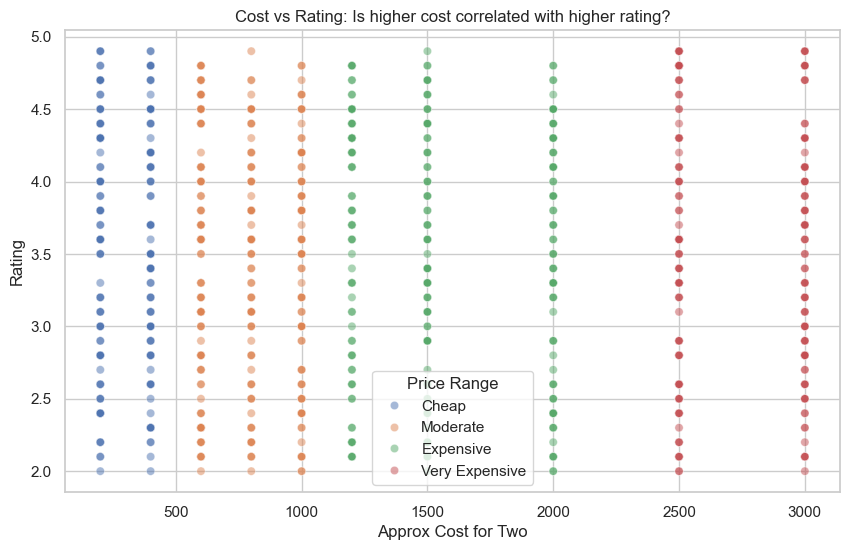

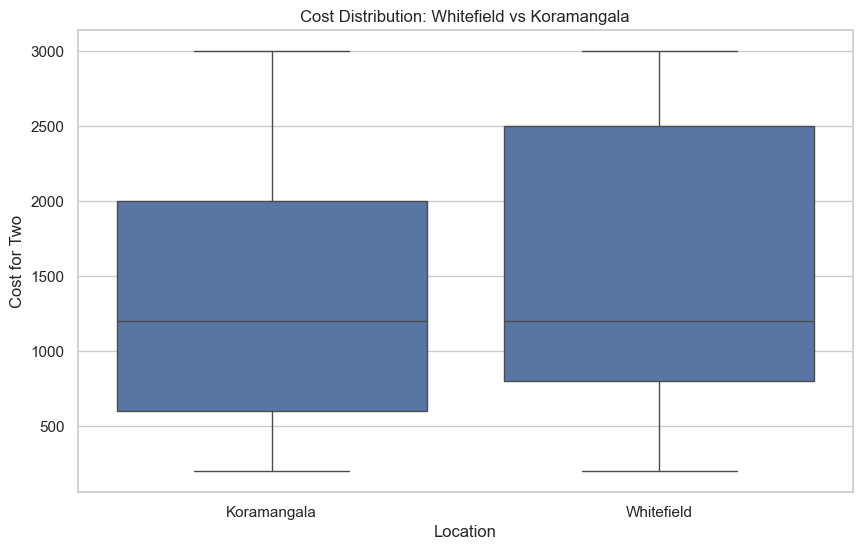

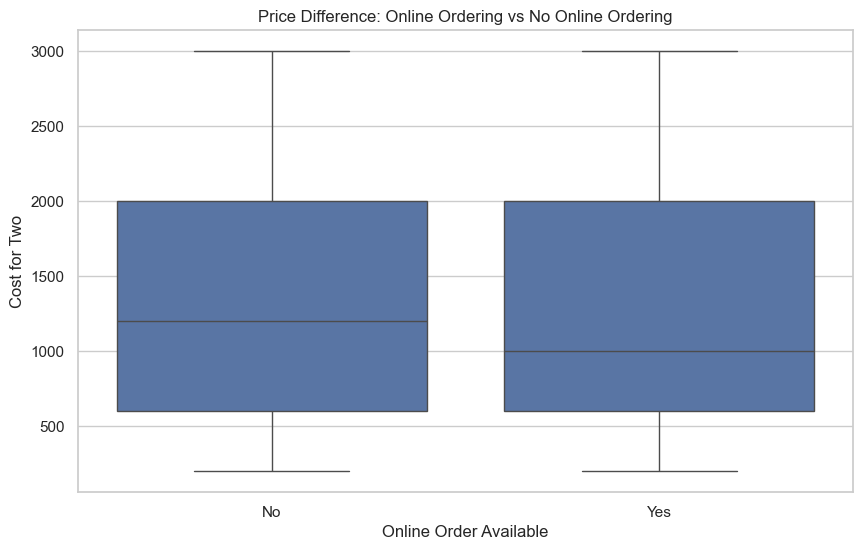

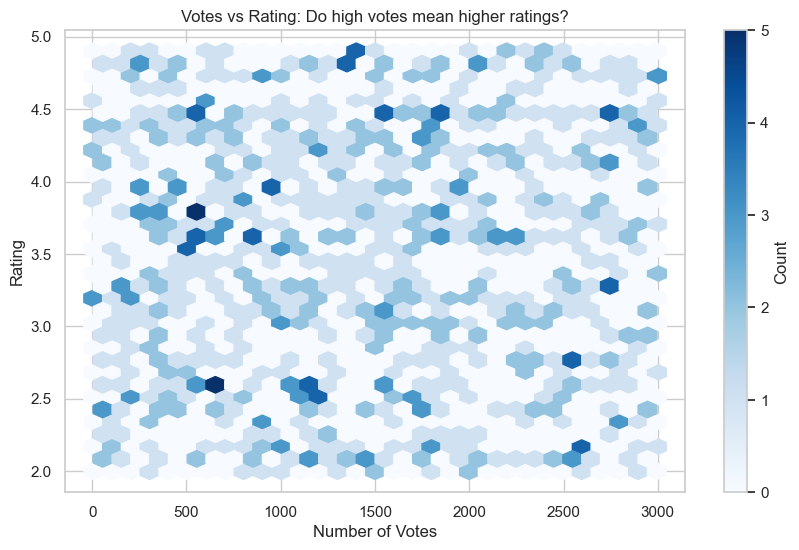

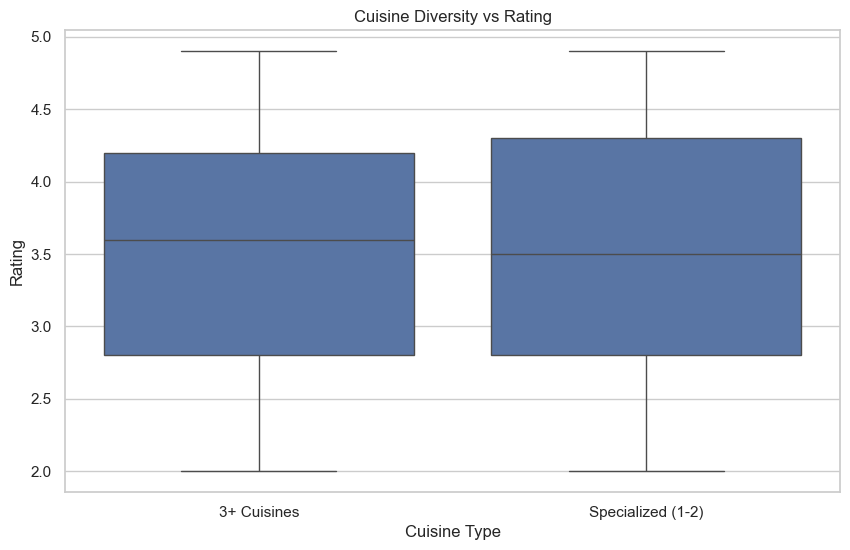

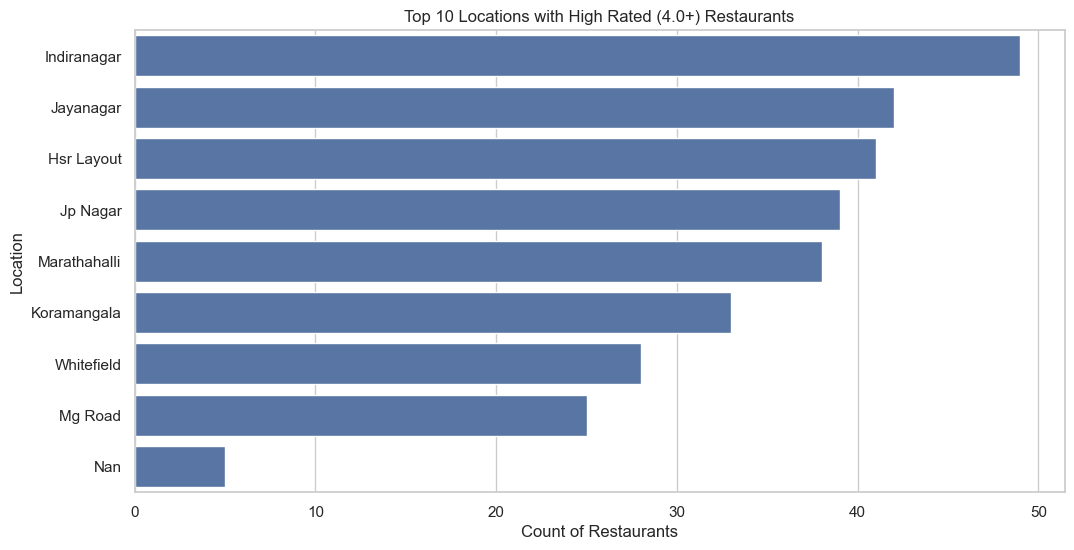

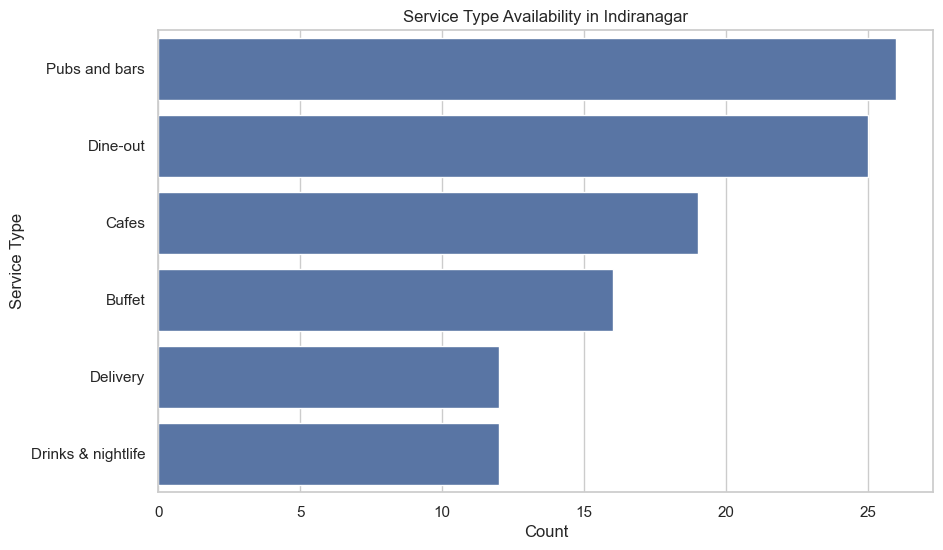

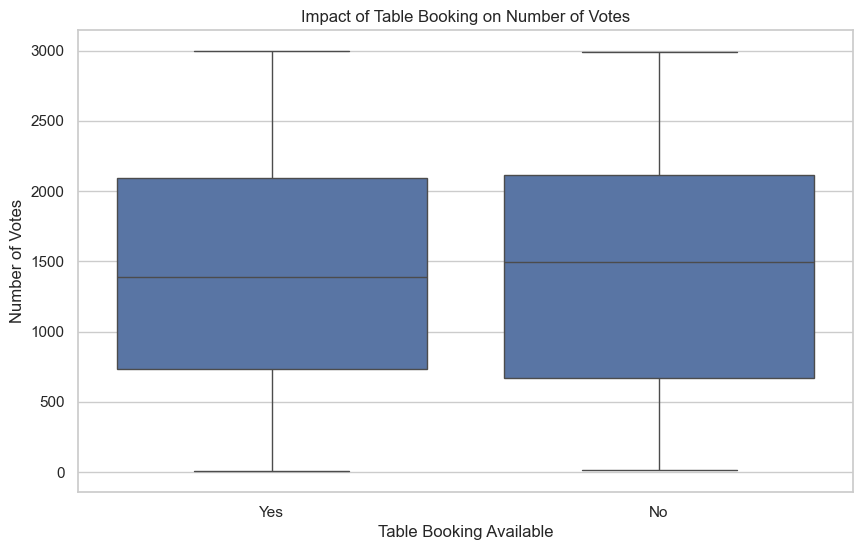

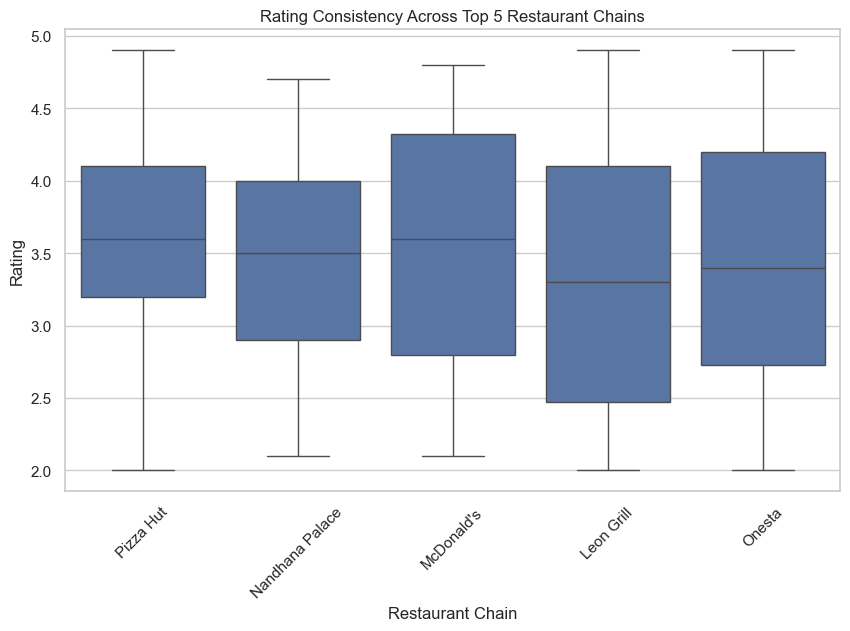

In [7]:

# =============================================================================
# SECTION 3: VISUALIZATIONS & ANALYSIS
# =============================================================================

# 1. MARKET & PRICING DYNAMICS

# 1.1 The Pricing Sweet Spot: Does higher cost correlate with higher rating?
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cost', y='rating', alpha=0.5, hue='price_range')
plt.title('Cost vs Rating: Is higher cost correlated with higher rating?')
plt.xlabel('Approx Cost for Two')
plt.ylabel('Rating')
plt.legend(title='Price Range')
plt.show()

# 1.2 Cost Distribution by Location: Whitefield vs Koramangala
plt.figure(figsize=(10, 6))
locations_to_compare = ['Whitefield', 'Koramangala']
df_filtered_loc = df[df['location'].isin(locations_to_compare)]
sns.boxplot(data=df_filtered_loc, x='location', y='cost')
plt.title('Cost Distribution: Whitefield vs Koramangala')
plt.xlabel('Location')
plt.ylabel('Cost for Two')
plt.show()

# 1.3 The Price of Online Convenience: Online Order vs No Online Order
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='online_order', y='cost')
plt.title('Price Difference: Online Ordering vs No Online Ordering')
plt.xlabel('Online Order Available')
plt.ylabel('Cost for Two')
plt.show()


# 2. DEEP DIVES INTO POPULARITY

# 2.1 The "Hype" Factor: Votes vs Rating
plt.figure(figsize=(10, 6))
# Using hexbin for large datasets to avoid overplotting
plt.hexbin(df['votes'], df['rating'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.title('Votes vs Rating: Do high votes mean higher ratings?')
plt.xlabel('Number of Votes')
plt.ylabel('Rating')
plt.show()

# 2.2 Cuisine Diversity vs Rating: 3+ cuisines vs Specialized
plt.figure(figsize=(10, 6))
df['cuisine_category'] = df['cuisine_count'].apply(lambda x: '3+ Cuisines' if x >= 3 else 'Specialized (1-2)')
sns.boxplot(data=df, x='cuisine_category', y='rating')
plt.title('Cuisine Diversity vs Rating')
plt.xlabel('Cuisine Type')
plt.ylabel('Rating')
plt.show()


# 3. GEOGRAPHICAL TRENDS

# 3.1 The "Foodie" Hubs: Locations with highest concentration of High Rated (4.0+) restaurants
plt.figure(figsize=(12, 6))
high_rated_df = df[df['rating'] >= 4.0]
top_locations = high_rated_df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title('Top 10 Locations with High Rated (4.0+) Restaurants')
plt.xlabel('Count of Restaurants')
plt.ylabel('Location')
plt.show()

# 3.2 Service Type Availability by Area: Indiranagar
plt.figure(figsize=(10, 6))
indiranagar_df = df[df['location'] == 'Indiranagar']
sns.countplot(data=indiranagar_df, y='service_type', order=indiranagar_df['service_type'].value_counts().index)
plt.title('Service Type Availability in Indiranagar')
plt.xlabel('Count')
plt.ylabel('Service Type')
plt.show()


# 4. OPERATIONAL INSIGHTS

# 4.1 Impact of Table Booking on Engagement (Votes)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='book_table', y='votes')
plt.title('Impact of Table Booking on Number of Votes')
plt.xlabel('Table Booking Available')
plt.ylabel('Number of Votes')
plt.show()

# 4.2 Rating Consistency across Chains (Top 5 Chains)
# Identify top 5 chains by frequency of name
top_chains = df['name'].value_counts().head(5).index
df_chains = df[df['name'].isin(top_chains)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_chains, x='name', y='rating')
plt.title('Rating Consistency Across Top 5 Restaurant Chains')
plt.xlabel('Restaurant Chain')
plt.ylabel('Rating')
plt.xticks(rotation=45)
plt.show()


In [4]:

# =============================================================================
# SECTION 4: EXPORTING RESULTS
# =============================================================================
# Save plots individually if needed for PDF submission
# Example: plt.savefig('pricing_sweet_spot.png')

print("\nAnalysis Complete. Please save the generated plots into a PDF for submission.")


Analysis Complete. Please save the generated plots into a PDF for submission.
